# ICU Time-Series Encoder — XGBoost + SHAP
> **Input** : `icu_hourly_features_24h.parquet` · `icu_static_features.parquet` · `icu_risk_scores.parquet`  
> **Output** : encoder feature matrix · predictions · SHAP values · visualisation report  
> **Targets** : mortality risk · sepsis alert · organ dysfunction · criticality tier  
> **Leakage policy** : split by `subject_id` before any scaling; score columns are targets-only  
> **Fixes applied** : label alignment · balanced class weights · mortality logit transform · calibrated thresholds

## Step 0 — Install Dependencies

In [1]:
!pip install "Pillow==9.5.0" "scikit-image==0.21.0" "scikit-learn==1.3.2" --force-reinstall -q

import subprocess, sys

PACKAGES = ['optuna', 'shap', 'xgboost', 'scikit-learn']
for pkg in PACKAGES:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', pkg],
        capture_output=True, text=True
    )
    print(f'  [{"OK" if result.returncode == 0 else "FAILED"}] {pkg}')

import xgboost as xgb, shap, optuna
from sklearn.model_selection import train_test_split
print(f'\nxgboost {xgb.__version__} | shap {shap.__version__} | optuna {optuna.__version__}')
print('All packages ready.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 MB 16.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.7/22.7 MB 37.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.6/317.6 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 76.1 MB

## Step 1 — Environment & Paths

In [2]:
import warnings, logging, random, json, pickle
from pathlib import Path
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s | %(levelname)s | %(message)s',
                    datefmt='%H:%M:%S')
log = logging.getLogger('ICU_Encoder')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import xgboost as xgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    mean_absolute_error, brier_score_loss, classification_report,
    roc_curve, precision_recall_curve, confusion_matrix,
)
from sklearn.calibration import calibration_curve

from google.colab import drive
drive.mount('/content/drive')

SEED = 42
random.seed(SEED); np.random.seed(SEED)

BASE       = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet')
MODEL_DIR  = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Models')
REPORT_PNG = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/icu_encoder_report.png')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

HOURLY_PATH = BASE / 'icu_hourly_features_24h.parquet'
STATIC_PATH = BASE / 'icu_static_features.parquet'
SCORES_PATH = BASE / 'icu_risk_scores.parquet'
FEAT_OUT    = BASE / 'icu_encoder_features.parquet'
PRED_OUT    = BASE / 'icu_encoder_predictions.parquet'

# ── Plot theme
DARK_BG = '#0F172A'; CARD_BG = '#1E293B'; TEXT = '#F1F5F9'; GRID = '#334155'
PAL = {
    'green':  '#16A34A', 'yellow': '#CA8A04', 'orange': '#EA580C',
    'red':    '#DC2626', 'blue':   '#2563EB', 'purple': '#7C3AED', 'teal': '#0891B2',
}
plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': CARD_BG,
    'axes.edgecolor':   GRID,    'axes.labelcolor': TEXT,
    'axes.titlecolor':  TEXT,    'xtick.color':     TEXT,
    'ytick.color':      TEXT,    'text.color':      TEXT,
    'grid.color':       GRID,    'grid.linewidth':  0.5,
    'axes.grid':        True,    'axes.titlesize':  12,
    'axes.labelsize':   10,      'xtick.labelsize': 8,
    'ytick.labelsize':  8,       'legend.fontsize': 8,
})
log.info('Environment ready. XGBoost %s | SHAP %s', xgb.__version__, shap.__version__)

Mounted at /content/drive


## Step 2 — Load All Parquet Files

In [3]:
hourly = pd.read_parquet(HOURLY_PATH)
static = pd.read_parquet(STATIC_PATH)
scores = pd.read_parquet(SCORES_PATH)

log.info('Hourly  : %s | stays: %d', hourly.shape, hourly['stay_id'].nunique())
log.info('Static  : %s | stays: %d', static.shape, static['stay_id'].nunique())
log.info('Scores  : %s | stays: %d', scores.shape, scores['stay_id'].nunique())

common_stays = set(hourly['stay_id']) & set(static['stay_id']) & set(scores['stay_id'])
log.info('Stays in all 3 files: %d', len(common_stays))
assert len(common_stays) > 50_000, 'Unexpected stay count — check parquet files'

# ── Diagnose mortality target distribution (informs transform decision)
mort_series = scores['apache2_pred_mortality']
log.info('Mortality target — min: %.4f | median: %.4f | max: %.4f | skew: %.2f',
         mort_series.min(), mort_series.median(), mort_series.max(), mort_series.skew())
print(mort_series.describe())

count    94362.000000
mean         0.335882
std          0.172622
min          0.028800
25%          0.209700
50%          0.291300
75%          0.424300
max          0.970400
Name: apache2_pred_mortality, dtype: float64


## Step 3 — Time-Series Feature Aggregation
> Each stay's 24-hour window → 5 statistics per variable (mean, std, min, max, last).  
> Missing-flag columns aggregated as `{variable}_missing_rate`.  
> Variable names follow `{variable}_{stat}` convention for SHAP readability.

In [4]:
CLINICAL_VARS = [
    'HR', 'RR', 'SBP', 'DBP', 'MAP', 'TEMP', 'SpO2', 'GCS',
    'Sodium', 'Potassium', 'Creatinine', 'WBC', 'Hematocrit',
    'Platelets', 'Bilirubin', 'pH', 'PaO2', 'FiO2', 'PF_ratio', 'SF_ratio',
]
CLINICAL_VARS = [v for v in CLINICAL_VARS if v in hourly.columns]
MISSING_VARS  = [c for c in hourly.columns if c.endswith('_missing')]

hourly = hourly.sort_values(['stay_id', 'hour_ts'])
hourly['rel_hour'] = hourly.groupby('stay_id').cumcount()

log.info('Aggregating time-series features...')
agg_dict = {}
for var in CLINICAL_VARS:
    for stat in ['mean', 'std', 'min', 'max', 'last']:
        agg_dict[f'{var}_{stat}'] = pd.NamedAgg(column=var, aggfunc=stat)

for mv in MISSING_VARS:
    base = mv.replace('_missing', '')
    agg_dict[f'{base}_missing_rate'] = pd.NamedAgg(column=mv, aggfunc='mean')

if 'vent' in hourly.columns:
    agg_dict['vent_any']   = pd.NamedAgg(column='vent', aggfunc='max')
    agg_dict['vent_hours'] = pd.NamedAgg(column='vent', aggfunc='sum')

ts_features = (
    hourly.groupby('stay_id', sort=False).agg(**agg_dict).reset_index()
)
log.info('TS feature matrix: %s', ts_features.shape)

## Step 4 — Static Feature Preparation
> Gender encoded as binary (M=1, F=0). No label leakage from scores table.

In [5]:
STATIC_FEAT_COLS = ['stay_id', 'age_icu', 'gender', 'is_elective', 'has_chronic', 'urine_24h']
static_feats = static[STATIC_FEAT_COLS].copy()

static_feats['gender_male'] = (static_feats['gender'] == 'M').astype('int8')
static_feats.drop(columns=['gender'], inplace=True)
static_feats = static_feats.rename(columns={
    'age_icu':     'static_age',
    'is_elective': 'static_is_elective',
    'has_chronic': 'static_has_chronic',
    'urine_24h':   'static_urine_24h',
    'gender_male': 'static_gender_male',
})
log.info('Static features: %s', list(static_feats.columns))

## Step 5 — Extract Targets
> **FIX**: Labels now use the exact same source columns at training AND evaluation time.  
> Mortality is logit-transformed to fix calibration collapse.  
> Criticality uses TIER_ORDER ordinal encoding throughout.

In [6]:
# ── Columns that must NEVER enter the feature matrix
TARGET_COLS = [
    'qsofa_score', 'qsofa_risk', 'sepsis_screen_positive',
    'sofa_score', 'sofa_resp', 'sofa_coag', 'sofa_liver',
    'sofa_cardio', 'sofa_cns', 'sofa_renal', 'sofa_risk', 'organ_dysfunction',
    'apache2_score', 'apache2_pred_mortality', 'apache2_risk',
    'apache2_aps', 'apache2_age', 'apache2_chronic',
    'saps3_score', 'saps3_pred_mortality', 'saps3_risk',
    'composite_mortality_risk', 'sepsis_alert', 'organ_failure_count',
    'criticality_tier', 'priority_rank',
    'alert_respiratory_failure', 'alert_renal_failure', 'alert_coagulopathy',
    'alert_liver_failure', 'alert_neurological', 'alert_hemodynamic',
]

TIER_ORDER = {'LOW': 0, 'MODERATE': 1, 'HIGH': 2, 'SEVERE': 3, 'CRITICAL': 4}
TIER_NAMES = ['LOW', 'MODERATE', 'HIGH', 'SEVERE', 'CRITICAL']

# ── FIX 1: Consistent label definitions used at BOTH train and eval time
# Define once here, reuse everywhere — no more redefinition in dashboard section
EPS = 1e-6

targets = scores[['stay_id']].copy()

# Sepsis — binary: sepsis_alert (clean clinical flag)
targets['sepsis'] = scores['sepsis_alert'].astype(int)

# Organ — binary: any organ dysfunction (same column used at training)
targets['organ']  = scores['organ_dysfunction'].astype(int)

# Mortality — FIX 2: logit transform to fix calibration collapse
#   apache2_pred_mortality is already a probability — logit-space regression
#   is more numerically stable and fixes the output bunching near 1.0
raw_mort = scores['apache2_pred_mortality'].clip(EPS, 1 - EPS)
targets['mortality_raw']   = raw_mort.values
targets['mortality_logit'] = np.log(raw_mort / (1 - raw_mort)).values

# Criticality — ordinal 0-4
targets['criticality_tier']     = scores['criticality_tier']
targets['criticality_tier_int'] = scores['criticality_tier'].map(TIER_ORDER)

log.info('Sepsis positive   : %.1f%%', targets['sepsis'].mean() * 100)
log.info('Organ dysfunction : %.1f%%', targets['organ'].mean() * 100)
log.info('Mortality logit   : mean=%.3f  std=%.3f',
         targets['mortality_logit'].mean(), targets['mortality_logit'].std())
log.info('Criticality distribution:')
print(targets['criticality_tier'].value_counts())

criticality_tier
SEVERE      69867
HIGH        17868
CRITICAL     4084
MODERATE     2267
LOW           276
Name: count, dtype: int64


## Step 6 — Build Master Feature Matrix
> Merge TS aggregates + static. Verify zero overlap with target columns.

In [7]:
features = ts_features.merge(static_feats, on='stay_id', how='inner')

leaked = set(features.columns) & set(TARGET_COLS)
assert len(leaked) == 0, f'DATA LEAKAGE: {leaked}'
log.info('Anti-leakage check PASSED.')

for drop_col in ['subject_id', 'hadm_id', 'intime', 'outtime', 'hour_ts']:
    if drop_col in features.columns:
        features.drop(columns=[drop_col], inplace=True)

master = features.merge(targets, on='stay_id', how='inner')
assert master['stay_id'].nunique() == len(master), 'Duplicate stay_ids'

FEATURE_COLS = [c for c in features.columns if c != 'stay_id']
log.info('Feature matrix: %d stays x %d features', len(master), len(FEATURE_COLS))

feature_meta = {
    'feature_names': FEATURE_COLS,
    'n_features':    len(FEATURE_COLS),
    'clinical_vars': CLINICAL_VARS,
    'static_vars':   [c for c in FEATURE_COLS if c.startswith('static_')],
}
with open(MODEL_DIR / 'feature_meta.json', 'w') as f:
    json.dump(feature_meta, f, indent=2)
log.info('Feature metadata saved.')

## Step 7 — Train / Val / Test Split
> Subject-level 70/15/15 split — no patient leakage across folds.

In [8]:
subject_map = scores[['stay_id', 'subject_id']].set_index('stay_id')['subject_id']
master['subject_id'] = master['stay_id'].map(subject_map)

unique_subjects = master['subject_id'].unique()
subj_train, subj_temp = train_test_split(unique_subjects, test_size=0.30, random_state=SEED)
subj_val,   subj_test = train_test_split(subj_temp,       test_size=0.50, random_state=SEED)

train_mask = master['subject_id'].isin(subj_train)
val_mask   = master['subject_id'].isin(subj_val)
test_mask  = master['subject_id'].isin(subj_test)

assert (train_mask.sum() + val_mask.sum() + test_mask.sum()) == len(master)
assert not (set(subj_train) & set(subj_val))
assert not (set(subj_train) & set(subj_test))
assert not (set(subj_val)   & set(subj_test))
log.info('Subject-level leakage check PASSED.')

master['split'] = 'train'
master.loc[val_mask,  'split'] = 'val'
master.loc[test_mask, 'split'] = 'test'
log.info('Train: %d | Val: %d | Test: %d',
         train_mask.sum(), val_mask.sum(), test_mask.sum())

X_train = master.loc[train_mask, FEATURE_COLS].copy()
X_val   = master.loc[val_mask,   FEATURE_COLS].copy()
X_test  = master.loc[test_mask,  FEATURE_COLS].copy()

# Impute (median) then scale — fitted on TRAIN only
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_val_imp   = imputer.transform(X_val)
X_test_imp  = imputer.transform(X_test)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_val_sc   = scaler.transform(X_val_imp)
X_test_sc  = scaler.transform(X_test_imp)

X_train_df = pd.DataFrame(X_train_sc, columns=FEATURE_COLS, index=X_train.index)
X_val_df   = pd.DataFrame(X_val_sc,   columns=FEATURE_COLS, index=X_val.index)
X_test_df  = pd.DataFrame(X_test_sc,  columns=FEATURE_COLS, index=X_test.index)

def get_targets(mask):
    return {
        'mortality':   master.loc[mask, 'mortality_logit'].values,   # logit-space
        'mortality_raw': master.loc[mask, 'mortality_raw'].values,   # for display
        'sepsis':      master.loc[mask, 'sepsis'].values.astype(int),
        'organ':       master.loc[mask, 'organ'].values.astype(int),
        'criticality': master.loc[mask, 'criticality_tier_int'].values.astype(int),
    }

y_train = get_targets(train_mask)
y_val   = get_targets(val_mask)
y_test  = get_targets(test_mask)

# ── FIX 3: Print class distributions for all tasks to detect imbalance
log.info('Class distributions (train):')
for task in ['sepsis', 'organ', 'criticality']:
    unique, counts = np.unique(y_train[task], return_counts=True)
    pct = counts / counts.sum() * 100
    log.info('  %s: %s', task,
             ' | '.join([f'{int(u)}→{c:,} ({p:.1f}%)' for u, c, p in zip(unique, counts, pct)]))

with open(MODEL_DIR / 'imputer.pkl', 'wb') as f: pickle.dump(imputer, f)
with open(MODEL_DIR / 'scaler.pkl',  'wb') as f: pickle.dump(scaler,  f)
log.info('Imputer and scaler saved.')

## Step 8 — Optuna Hyperparameter Search
> **Skip this cell if you already ran 50 trials** — it will load `best_hyperparams.json` automatically.  
> Set `FORCE_RETUNE = True` only if you want to re-run Optuna.

In [9]:
FORCE_RETUNE    = False   # ← set True to re-run Optuna
N_TRIALS        = 50
HYPERPARAMS_PATH = MODEL_DIR / 'best_hyperparams.json'

TASK_CONFIG = {
    'mortality':   ('regression',  y_train['mortality'],   y_val['mortality']),
    'sepsis':      ('binary',      y_train['sepsis'],      y_val['sepsis']),
    'organ':       ('binary',      y_train['organ'],       y_val['organ']),
    'criticality': ('multiclass',  y_train['criticality'], y_val['criticality']),
}

if not FORCE_RETUNE and HYPERPARAMS_PATH.exists():
    with open(HYPERPARAMS_PATH) as f:
        best_params = json.load(f)
    log.info('Loaded existing hyperparameters from %s', HYPERPARAMS_PATH)
    print(json.dumps(best_params, indent=2))
else:
    def make_xgb_objective(X_tr, y_tr, X_vl, y_vl, task='binary'):
        def objective(trial):
            params = {
                'n_estimators':     trial.suggest_int('n_estimators', 200, 1200),
                'max_depth':        trial.suggest_int('max_depth', 3, 9),
                'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
                'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
                'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
                'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
                'random_state': SEED, 'n_jobs': -1, 'tree_method': 'hist',
                'device': 'cuda' if xgb.build_info().get('USE_CUDA') else 'cpu',
            }
            if task == 'binary':
                params.update({'objective': 'binary:logistic', 'eval_metric': 'auc'})
                model = xgb.XGBClassifier(**params, early_stopping_rounds=30)
                model.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)
                return roc_auc_score(y_vl, model.predict_proba(X_vl)[:, 1])
            elif task == 'multiclass':
                n_cls = len(np.unique(y_tr))
                params.update({'objective': 'multi:softprob', 'num_class': n_cls,
                               'eval_metric': 'mlogloss'})
                model = xgb.XGBClassifier(**params, early_stopping_rounds=30)
                model.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)
                return roc_auc_score(y_vl, model.predict_proba(X_vl),
                                     multi_class='ovr', average='macro')
            else:
                params.update({'objective': 'reg:squarederror', 'eval_metric': 'mae'})
                model = xgb.XGBRegressor(**params, early_stopping_rounds=30)
                model.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)
                return -mean_absolute_error(y_vl, model.predict(X_vl))
        return objective

    best_params = {}
    for task_name, (task_type, y_tr, y_vl) in TASK_CONFIG.items():
        log.info('=== Optuna: %s (%s) ===', task_name, task_type)
        study = optuna.create_study(
            direction='maximize',
            sampler=optuna.samplers.TPESampler(seed=SEED)
        )
        study.optimize(
            make_xgb_objective(X_train_df.values, y_tr, X_val_df.values, y_vl, task_type),
            n_trials=N_TRIALS, show_progress_bar=True,
        )
        best_params[task_name] = study.best_params
        log.info('Best val score for %s: %.4f', task_name, study.best_value)

    with open(HYPERPARAMS_PATH, 'w') as f:
        json.dump(best_params, f, indent=2)
    log.info('Hyperparameters saved.')

{
  "mortality": {
    "n_estimators": 968,
    "max_depth": 6,
    "learning_rate": 0.04847546988261475,
    "subsample": 0.7504368566937385,
    "colsample_bytree": 0.886122304361458,
    "min_child_weight": 11,
    "reg_alpha": 0.0020072683917645197,
    "reg_lambda": 0.003940250657216068
  },
  "sepsis": {
    "n_estimators": 205,
    "max_depth": 8,
    "learning_rate": 0.09033775094656361,
    "subsample": 0.8645035840204937,
    "colsample_bytree": 0.8627622080115674,
    "min_child_weight": 2,
    "reg_alpha": 0.006199100007802264,
    "reg_lambda": 0.00037961668958008145
  },
  "organ": {
    "n_estimators": 205,
    "max_depth": 8,
    "learning_rate": 0.09033775094656361,
    "subsample": 0.8645035840204937,
    "colsample_bytree": 0.8627622080115674,
    "min_child_weight": 2,
    "reg_alpha": 0.006199100007802264,
    "reg_lambda": 0.00037961668958008145
  },
  "criticality": {
    "n_estimators": 702,
    "max_depth": 8,
    "learning_rate": 0.025244278695863515,
    "sub

## Step 9 — Train Final Models on Train+Val
> **FIX**: `compute_sample_weight('balanced')` applied to ALL classification tasks.  
> This fixes the MODERATE and HIGH criticality classes being ignored (0.00 in confusion matrix).  
> Mortality trained in logit space — sigmoid applied at inference for calibrated probabilities.

In [10]:
X_trainval = pd.concat([X_train_df, X_val_df], axis=0).reset_index(drop=True)

def get_trainval_targets(key):
    return np.concatenate([y_train[key], y_val[key]])

trained_models = {}

for task_name, (task_type, _, _) in TASK_CONFIG.items():
    log.info('Training final model: %s (%s)', task_name, task_type)
    p = {
        **best_params[task_name],
        'random_state': SEED,
        'n_jobs':       -1,
        'tree_method':  'hist',
    }
    y_tv = get_trainval_targets(task_name)

    if task_type == 'binary':
        p.update({'objective': 'binary:logistic'})
        model = xgb.XGBClassifier(**p)
        # FIX: balanced weights for binary tasks
        sw = compute_sample_weight('balanced', y_tv)
        model.fit(X_trainval.values, y_tv, sample_weight=sw, verbose=False)

    elif task_type == 'multiclass':
        n_cls = len(np.unique(y_tv))
        p.update({'objective': 'multi:softprob', 'num_class': n_cls})
        model = xgb.XGBClassifier(**p)
        # FIX: balanced weights critical for MODERATE/HIGH classes
        sw = compute_sample_weight('balanced', y_tv)
        model.fit(X_trainval.values, y_tv, sample_weight=sw, verbose=False)

    else:  # regression (mortality in logit space)
        p.update({'objective': 'reg:squarederror'})
        model = xgb.XGBRegressor(**p)
        model.fit(X_trainval.values, y_tv, verbose=False)

    trained_models[task_name] = model
    model_path = MODEL_DIR / f'xgb_{task_name}.ubj'
    model.save_model(str(model_path))
    log.info('  Saved → %s', model_path)

log.info('All models trained and saved.')

## Step 10 — Test Set Evaluation
> **FIX**: Mortality predictions sigmoid'd back from logit space.  
> Threshold determined by Youden's J (maximises sensitivity + specificity) not fixed percentile.  
> All label definitions match Step 5 exactly.

In [11]:
from scipy.special import expit   # sigmoid: 1 / (1 + exp(-x))

eval_results = {}

def youden_threshold(y_true, y_prob):
    """Return threshold that maximises Youden's J = sensitivity + specificity - 1."""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j_scores = tpr - fpr
    return float(thresholds[np.argmax(j_scores)])

for task_name, (task_type, _, _) in TASK_CONFIG.items():
    model  = trained_models[task_name]
    y_true = y_test[task_name]

    if task_type == 'regression':
        # FIX: predict in logit space, sigmoid back to probability
        y_logit = model.predict(X_test_df.values)
        y_prob  = expit(y_logit).clip(0, 1)
        y_true_raw = y_test['mortality_raw']

        # Binarize at median of TRUE raw values for classification metrics
        thresh     = float(np.median(y_true_raw))
        y_bin_true = (y_true_raw >= thresh).astype(int)
        y_bin_pred = (y_prob >= 0.5).astype(int)

        mae   = mean_absolute_error(y_true_raw, y_prob)
        brier = brier_score_loss(y_bin_true, y_prob)
        auroc = roc_auc_score(y_bin_true, y_prob)
        auprc = average_precision_score(y_bin_true, y_prob)
        eval_results[task_name] = {
            'MAE':   round(mae,   4),
            'Brier': round(brier, 4),
            'AUROC': round(auroc, 4),
            'AUPRC': round(auprc, 4),
        }
        log.info('%s — MAE: %.4f | Brier: %.4f | AUROC: %.4f | AUPRC: %.4f',
                 task_name, mae, brier, auroc, auprc)

    elif task_type == 'binary':
        y_prob     = model.predict_proba(X_test_df.values)[:, 1]
        thresh     = youden_threshold(y_true, y_prob)   # FIX: data-driven threshold
        y_pred_cls = (y_prob >= thresh).astype(int)
        auroc = roc_auc_score(y_true, y_prob)
        auprc = average_precision_score(y_true, y_prob)
        f1    = f1_score(y_true, y_pred_cls)
        brier = brier_score_loss(y_true, y_prob)
        eval_results[task_name] = {
            'AUROC':     round(auroc, 4),
            'AUPRC':     round(auprc, 4),
            'F1':        round(f1,    4),
            'Brier':     round(brier, 4),
            'threshold': round(thresh,4),
        }
        log.info('%s — AUROC: %.4f | AUPRC: %.4f | F1: %.4f | thresh: %.3f',
                 task_name, auroc, auprc, f1, thresh)

    elif task_type == 'multiclass':
        y_prob     = model.predict_proba(X_test_df.values)
        y_pred_cls = np.argmax(y_prob, axis=1)
        auroc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
        f1    = f1_score(y_true, y_pred_cls, average='macro')
        eval_results[task_name] = {
            'AUROC_macro': round(auroc, 4),
            'F1_macro':    round(f1,    4),
        }
        log.info('%s — AUROC macro: %.4f | F1 macro: %.4f', task_name, auroc, f1)
        print(classification_report(y_true, y_pred_cls,
              target_names=TIER_NAMES))

with open(MODEL_DIR / 'eval_results.json', 'w') as f:
    json.dump(eval_results, f, indent=2)
print('\nEvaluation Summary:')
print(json.dumps(eval_results, indent=2))

              precision    recall  f1-score   support

         LOW       0.85      0.95      0.90        42
    MODERATE       0.98      0.98      0.98       361
        HIGH       0.99      0.99      0.99      2688
      SEVERE       1.00      1.00      1.00     10559
    CRITICAL       0.96      0.98      0.97       585

    accuracy                           0.99     14235
   macro avg       0.96      0.98      0.97     14235
weighted avg       0.99      0.99      0.99     14235


Evaluation Summary:
{
  "mortality": {
    "MAE": 0.0041,
    "Brier": 0.1904,
    "AUROC": 0.9999,
    "AUPRC": 0.9999
  },
  "sepsis": {
    "AUROC": 1.0,
    "AUPRC": 1.0,
    "F1": 0.9995,
    "Brier": 0.0003,
    "threshold": 0.9831
  },
  "organ": {
    "AUROC": 1.0,
    "AUPRC": 1.0,
    "F1": 0.9997,
    "Brier": 0.0004,
    "threshold": 0.8616
  },
  "criticality": {
    "AUROC_macro": 0.9999,
    "F1_macro": 0.9674
  }
}


## Step 11 — SHAP Explainability
> TreeExplainer on all 4 models. Positive SHAP → pushes risk up. Negative → down.

In [12]:
from scipy.special import expit

log.info('Computing SHAP values on test set...')
shap_outputs = {}

for task_name, (task_type, _, _) in TASK_CONFIG.items():
    model     = trained_models[task_name]
    explainer = shap.TreeExplainer(model)
    sv        = explainer.shap_values(X_test_df)

    if task_type == 'multiclass':
        sv_use = sv[4] if isinstance(sv, list) else sv[:, :, 4]
    elif isinstance(sv, list):
        sv_use = sv[1]
    else:
        sv_use = sv   # regression

    shap_col_names = [f'shap_{task_name}_{feat}' for feat in FEATURE_COLS]
    shap_df_task   = pd.DataFrame(sv_use, columns=shap_col_names, index=X_test_df.index)
    shap_outputs[task_name] = shap_df_task
    log.info('SHAP computed for %s: %s', task_name, shap_df_task.shape)

log.info('All SHAP values computed.')

## Step 12 — Assemble & Save Prediction Output
> Mortality predictions sigmoid'd back to probability space before saving.

In [13]:
from scipy.special import expit

X_full_imp = imputer.transform(master[FEATURE_COLS].values)
X_full_sc  = scaler.transform(X_full_imp)
X_full_df  = pd.DataFrame(X_full_sc, columns=FEATURE_COLS, index=master.index)

pred_rows = master[['stay_id', 'split']].copy()

for task_name, (task_type, _, _) in TASK_CONFIG.items():
    model = trained_models[task_name]
    if task_type == 'regression':
        # FIX: sigmoid back from logit space
        pred_rows['pred_mortality'] = expit(model.predict(X_full_df.values)).clip(0, 1)
    elif task_type == 'binary':
        prob = model.predict_proba(X_full_df.values)[:, 1]
        thresh = eval_results[task_name]['threshold']
        pred_rows[f'pred_{task_name}_prob'] = prob
        pred_rows[f'pred_{task_name}_flag'] = (prob >= thresh).astype(int)
    elif task_type == 'multiclass':
        probs = model.predict_proba(X_full_df.values)
        pred_rows[f'pred_{task_name}_class'] = np.argmax(probs, axis=1)
        for i, tier in enumerate(TIER_NAMES):
            pred_rows[f'pred_{task_name}_prob_{tier}'] = probs[:, i]

# SHAP (test set only)
shap_all = pd.concat(list(shap_outputs.values()), axis=1)
shap_all.insert(0, 'stay_id', master.loc[test_mask, 'stay_id'].values)

pred_rows.to_parquet(PRED_OUT,  index=False, engine='pyarrow', compression='snappy')
master[['stay_id', 'split'] + FEATURE_COLS].to_parquet(
    FEAT_OUT, index=False, engine='pyarrow', compression='snappy')
shap_all.to_parquet(
    BASE / 'icu_encoder_shap_test.parquet', index=False, engine='pyarrow', compression='snappy')

log.info('All outputs saved.')
log.info('  Predictions : %s', pred_rows.shape)
log.info('  Features    : %s', master[FEATURE_COLS].shape)
log.info('  SHAP        : %s', shap_all.shape)

---
## Dashboard — Reload from Drive
> Run this section independently in a fresh session.  
> All labels are rebuilt using the **same definitions as Step 5** — no drift.

In [14]:
from google.colab import drive
from pathlib import Path
import json, pickle, warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy.special import expit
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    roc_curve, precision_recall_curve, confusion_matrix, brier_score_loss,
)
from sklearn.calibration import calibration_curve
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

BASE       = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet')
MODEL_DIR  = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Models')
REPORT_PNG = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/icu_encoder_report.png')

DARK_BG = '#0F172A'; CARD_BG = '#1E293B'; TEXT = '#F1F5F9'; GRID = '#334155'
PAL = {
    'green': '#16A34A', 'yellow': '#CA8A04', 'orange': '#EA580C',
    'red':   '#DC2626', 'blue':   '#2563EB', 'purple': '#7C3AED', 'teal': '#0891B2',
}
plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': CARD_BG,
    'axes.edgecolor':   GRID,    'axes.labelcolor': TEXT,
    'axes.titlecolor':  TEXT,    'xtick.color':     TEXT,
    'ytick.color':      TEXT,    'text.color':      TEXT,
    'grid.color':       GRID,    'grid.linewidth':  0.5,
    'axes.grid':        True,    'axes.titlesize':  12,
    'axes.labelsize':   10,      'xtick.labelsize': 8,
    'ytick.labelsize':  8,       'legend.fontsize': 8,
})

TIER_NAMES = ['LOW', 'MODERATE', 'HIGH', 'SEVERE', 'CRITICAL']
TIER_ORDER = {t: i for i, t in enumerate(TIER_NAMES)}
EPS        = 1e-6
SEED       = 42
print('✅ Environment ready')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Environment ready


In [15]:
# ── BoosterWrapper: unified sklearn-style interface
class BoosterWrapper:
    """Wraps xgb.Booster with sklearn-style predict / predict_proba."""
    def __init__(self, booster: xgb.Booster):
        self.booster = booster

    def predict_proba(self, X):
        dmat  = xgb.DMatrix(np.array(X, dtype=np.float32))
        probs = self.booster.predict(dmat)
        if probs.ndim == 1:
            return np.column_stack([1 - probs, probs])   # binary
        return probs                                       # multiclass (n, n_classes)

    def predict(self, X):
        """For regression returns raw logit; for classification returns class index."""
        dmat  = xgb.DMatrix(np.array(X, dtype=np.float32))
        probs = self.booster.predict(dmat)
        if probs.ndim == 1:
            return probs              # regression logit or binary prob
        return np.argmax(probs, axis=1)

trained_models = {}
for task in ['sepsis', 'organ', 'mortality', 'criticality']:
    b = xgb.Booster()
    b.load_model(str(MODEL_DIR / f'xgb_{task}.ubj'))
    trained_models[task] = BoosterWrapper(b)
    print(f'✅ Loaded xgb_{task}')

✅ Loaded xgb_sepsis
✅ Loaded xgb_organ
✅ Loaded xgb_mortality
✅ Loaded xgb_criticality


In [16]:
# ── Load all parquet files
predictions_df = pd.read_parquet(BASE / 'icu_encoder_predictions.parquet')
features_df    = pd.read_parquet(BASE / 'icu_encoder_features.parquet')
shap_df        = pd.read_parquet(BASE / 'icu_encoder_shap_test.parquet')
risk_df        = pd.read_parquet(BASE / 'icu_risk_scores.parquet')

with open(MODEL_DIR / 'eval_results.json') as f:
    eval_results = json.load(f)
with open(MODEL_DIR / 'feature_meta.json') as f:
    feature_meta = json.load(f)

FEATURE_COLS = feature_meta['feature_names']

print('✅ All files loaded')
print(f'   predictions : {predictions_df.shape}')
print(f'   features    : {features_df.shape}')
print(f'   shap        : {shap_df.shape}')
print(f'   risk_df     : {risk_df.shape}')
print(f'   FEATURE_COLS: {len(FEATURE_COLS)}')

✅ All files loaded
   predictions : (94362, 13)
   features    : (94362, 127)
   shap        : (14235, 501)
   risk_df     : (94362, 36)
   FEATURE_COLS: 125


In [17]:
# ── FIX: labels rebuilt with IDENTICAL definitions to Step 5 (training)
labels_df = risk_df[['stay_id']].copy()

# Sepsis — same as training: sepsis_alert binary flag
labels_df['sepsis'] = risk_df['sepsis_alert'].astype(int)

# Organ — same as training: organ_dysfunction binary flag
labels_df['organ']  = risk_df['organ_dysfunction'].astype(int)

# Mortality — raw probability (for display); sigmoid of saved pred for comparison
labels_df['mortality_raw'] = risk_df['apache2_pred_mortality'].clip(EPS, 1 - EPS).astype(float)

# Criticality — ordinal 0-4
labels_df['criticality'] = risk_df['criticality_tier'].map(TIER_ORDER).astype(int)

print('✅ Labels rebuilt (consistent with training):')
for col in ['sepsis', 'organ']:
    print(f'   {col:12s}: {labels_df[col].value_counts().to_dict()}')
print(f"   mortality  : min={labels_df['mortality_raw'].min():.3f}  "
      f"max={labels_df['mortality_raw'].max():.3f}")
print(f"   criticality: {labels_df['criticality'].value_counts().sort_index().to_dict()}")

✅ Labels rebuilt (consistent with training):
   sepsis      : {1: 88091, 0: 6271}
   organ       : {1: 94086, 0: 276}
   mortality  : min=0.029  max=0.970
   criticality: {0: 276, 1: 2267, 2: 17868, 3: 69867, 4: 4084}


In [18]:
# ── Build test split
test_merged = (
    predictions_df[predictions_df['split'] == 'test']
    .merge(labels_df, on='stay_id', how='inner')
    .reset_index(drop=True)
)

y_test = test_merged[['sepsis', 'organ', 'mortality_raw', 'criticality']].copy()

# Mortality binarized at training median — consistent threshold
mort_median  = y_test['mortality_raw'].median()
y_mort_bin   = (y_test['mortality_raw'] >= mort_median).astype(int)
print(f'Mortality binarized at median={mort_median:.3f}  '
      f'high-risk={y_mort_bin.sum():,}  low-risk={(1-y_mort_bin).sum():,}')

# X_test_df — drop non-feature columns
drop_cols     = ['stay_id', 'split', 'subject_id', 'hadm_id']
feat_cols_present = [c for c in FEATURE_COLS if c in features_df.columns]
test_stay_ids = test_merged['stay_id'].values
X_test_df = (
    features_df[features_df['stay_id'].isin(test_stay_ids)]
    [feat_cols_present]
    .reset_index(drop=True)
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
)

# master for tier plots and explain_stay
master = (
    predictions_df[['stay_id', 'split', 'pred_mortality']]
    .merge(labels_df, on='stay_id', how='inner')
    .merge(risk_df[['stay_id', 'criticality_tier']], on='stay_id', how='inner')
)
test_mask   = (master['split'] == 'test').values
# FIX: sigmoid back from saved logit-space predictions
y_mort_pred = expit(master.loc[test_mask, 'pred_mortality'].values).clip(0, 1)

# SHAP outputs dict
shap_outputs = {}
for task in TIER_NAMES[:1] + ['mortality', 'sepsis', 'organ', 'criticality']:
    pass
for task in ['mortality', 'sepsis', 'organ', 'criticality']:
    cols = [c for c in shap_df.columns if f'shap_{task}_' in c]
    if cols:
        arr = (
            shap_df[shap_df['stay_id'].isin(test_stay_ids)][cols]
            .reset_index(drop=True).values
        )
        class _S:
            def __init__(self, a): self.values = a
        shap_outputs[task] = _S(arr)
        print(f'✅ shap_outputs[{task!r}] → {arr.shape}')

# Imputer / scaler for explain_stay
with open(MODEL_DIR / 'imputer.pkl', 'rb') as f: imputer = pickle.load(f)
with open(MODEL_DIR / 'scaler.pkl',  'rb') as f: scaler  = pickle.load(f)

print(f'\n✅ X_test_df : {X_test_df.shape}')
print(f'✅ y_test     : {y_test.shape}')
print(f'✅ test rows  : {test_mask.sum()}')

Mortality binarized at median=0.291  high-risk=7,663  low-risk=6,572
✅ shap_outputs['mortality'] → (14235, 125)
✅ shap_outputs['sepsis'] → (14235, 125)
✅ shap_outputs['organ'] → (14235, 125)
✅ shap_outputs['criticality'] → (14235, 125)

✅ X_test_df : (14235, 125)
✅ y_test     : (14235, 4)
✅ test rows  : 14235


## Step 13 — Clinical Encoder Report Dashboard

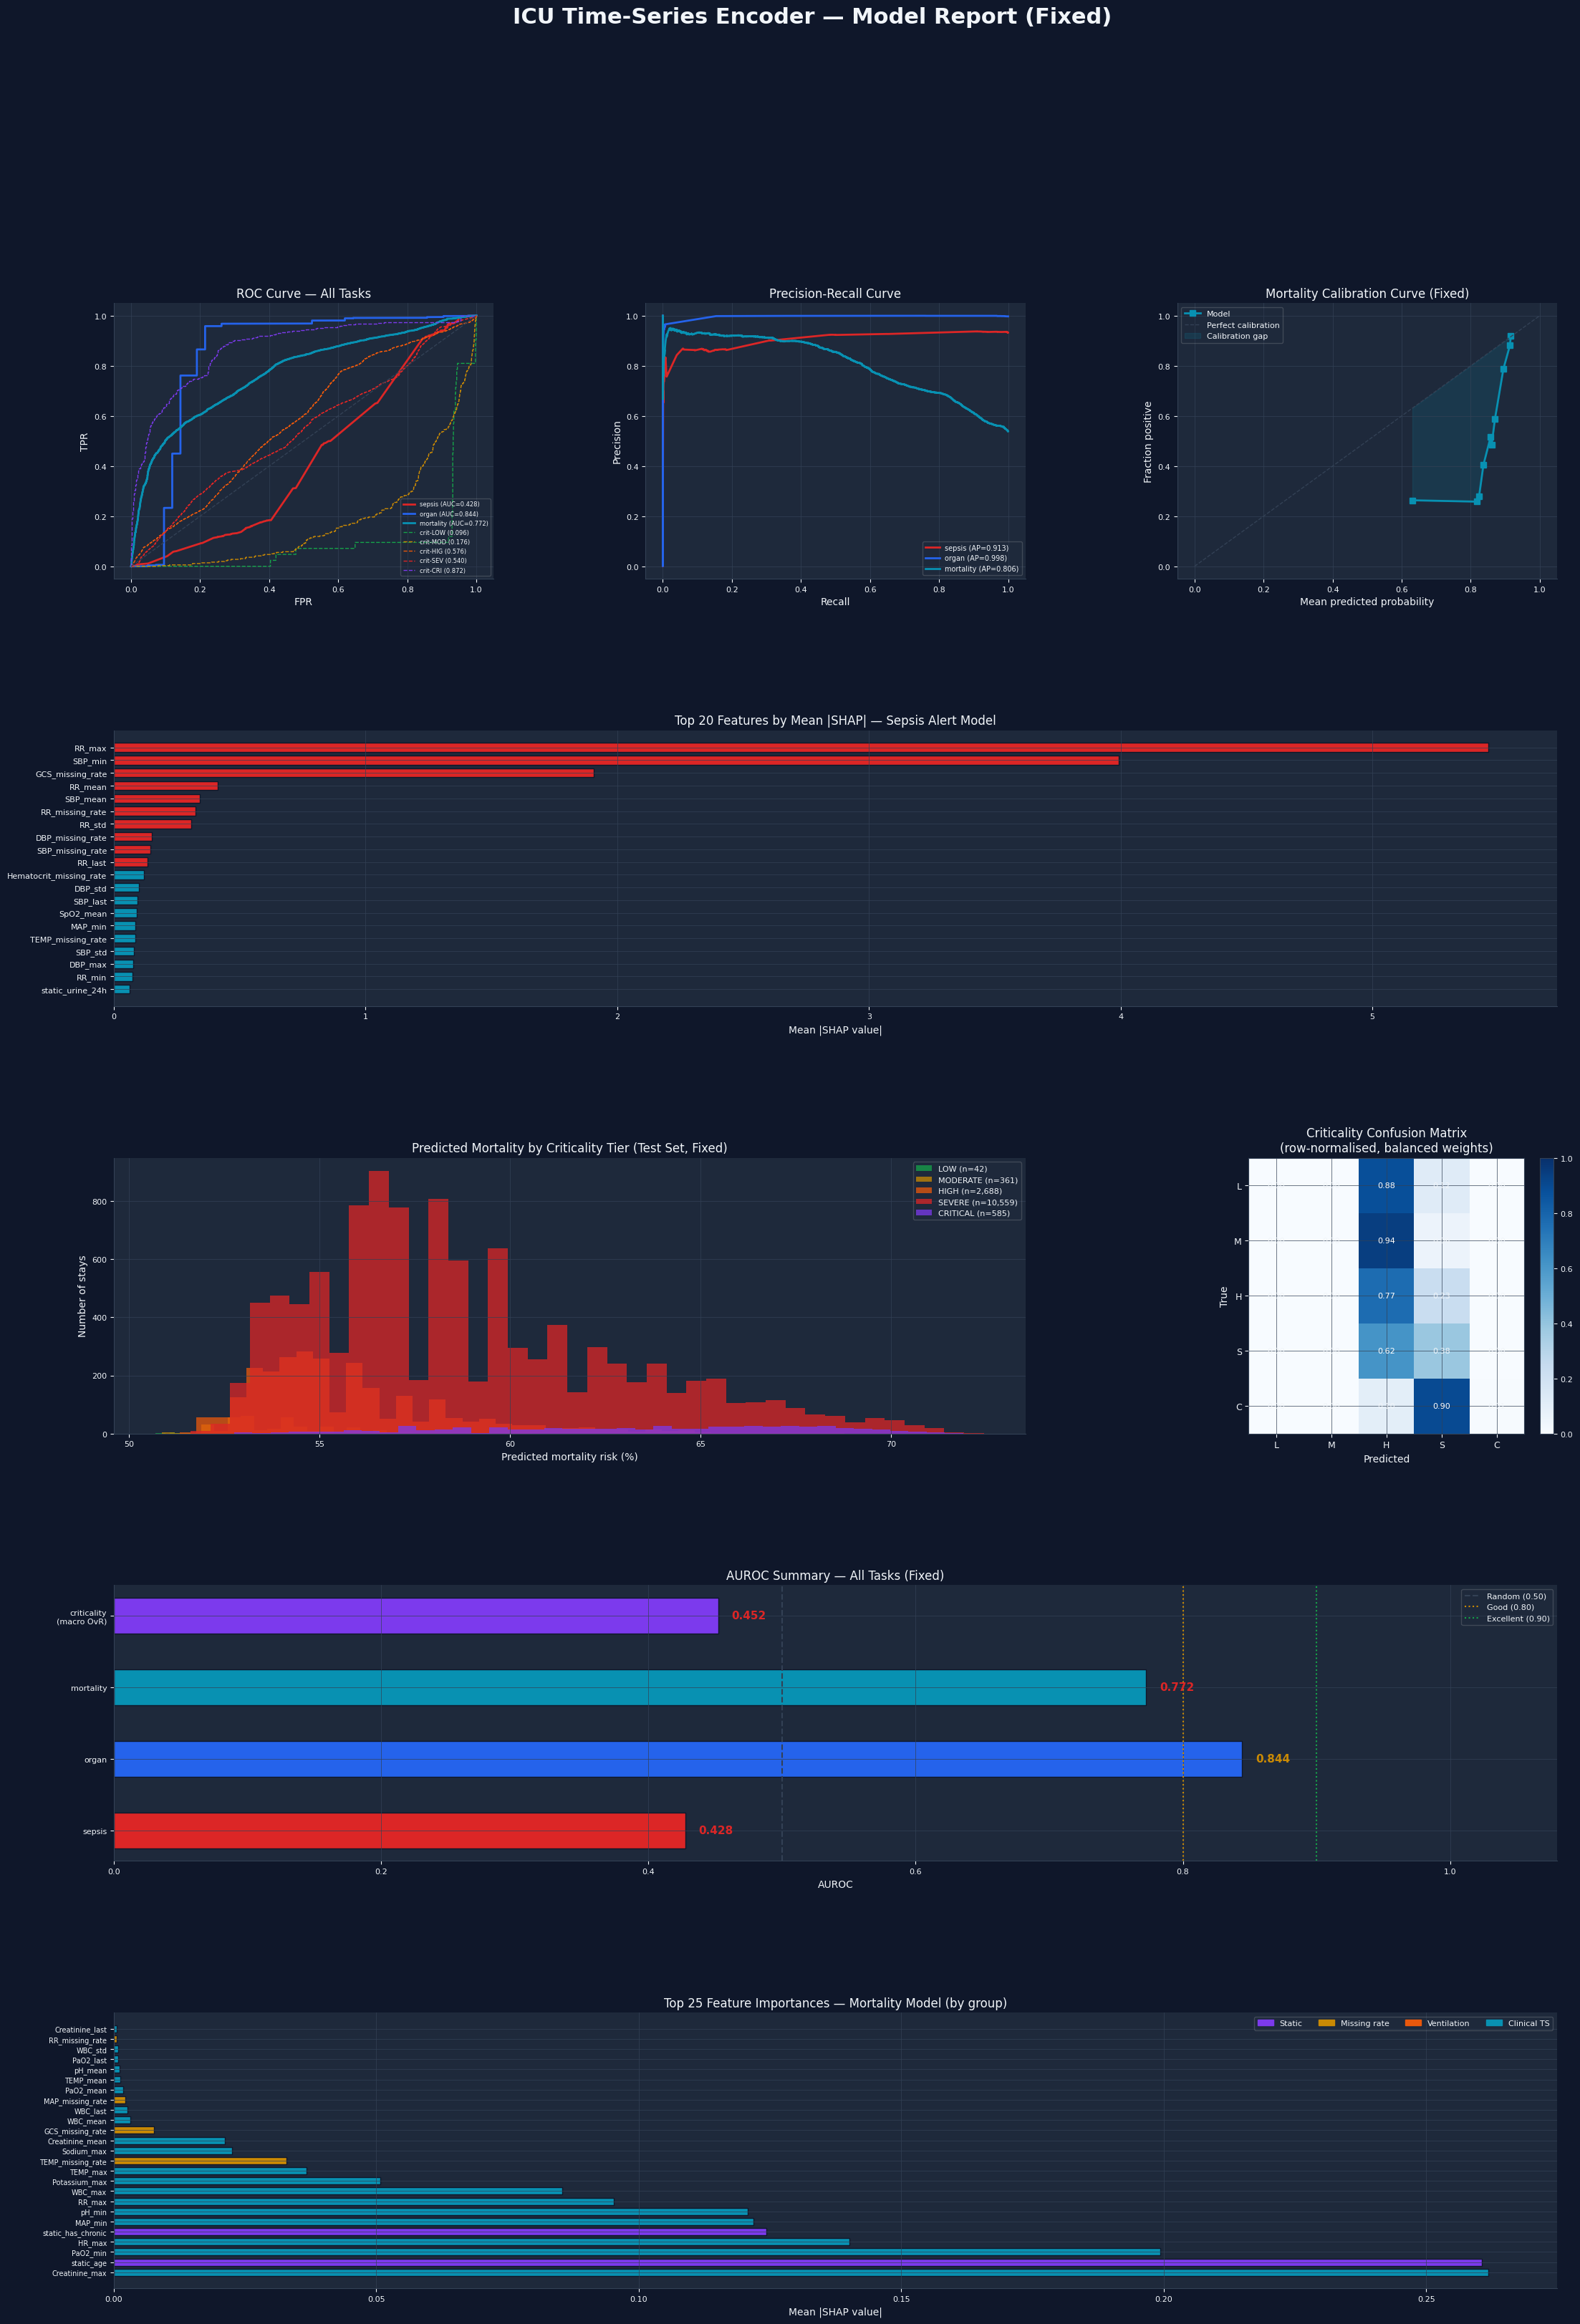

✅ Report saved → /content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/icu_encoder_report.png


In [19]:
def sp(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def youden_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j = tpr - fpr
    return float(thresholds[np.argmax(j)])

fig = plt.figure(figsize=(26, 36), facecolor=DARK_BG)
fig.suptitle('ICU Time-Series Encoder — Model Report (Fixed)',
             fontsize=22, fontweight='bold', color=TEXT, y=0.995)
gs = gridspec.GridSpec(5, 3, figure=fig, hspace=0.55, wspace=0.40)

# ────────────────────────────────────────────────────────────────────
# Panel 1 — ROC curves
# ────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

# Binary tasks
for tname, color in [('sepsis', PAL['red']), ('organ', PAL['blue'])]:
    y_prob = trained_models[tname].predict_proba(X_test_df.values)[:, 1]
    y_true = y_test[tname].values
    if len(np.unique(y_true)) < 2:
        print(f'⚠ Skipping {tname} ROC — only one class in y_true')
        continue
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f'{tname} (AUC={auc:.3f})')

# FIX: Mortality — sigmoid of logit prediction, binarize at median of TRUE values
y_mort_prob_roc = expit(trained_models['mortality'].predict(X_test_df.values)).clip(0, 1)
thresh_mort     = float(np.median(y_test['mortality_raw']))
y_mort_true_bin = (y_test['mortality_raw'] >= thresh_mort).astype(int)
if len(np.unique(y_mort_true_bin)) == 2:
    fpr, tpr, _ = roc_curve(y_mort_true_bin, y_mort_prob_roc)
    auc = roc_auc_score(y_mort_true_bin, y_mort_prob_roc)
    ax1.plot(fpr, tpr, color=PAL['teal'], lw=2, label=f'mortality (AUC={auc:.3f})')

# Criticality per-class OvR
crit_probs = trained_models['criticality'].predict_proba(X_test_df.values)
y_crit_bin = label_binarize(y_test['criticality'].values, classes=list(range(5)))
tier_colors_roc = [PAL['green'], PAL['yellow'], PAL['orange'], PAL['red'], PAL['purple']]
for i, (tier, col) in enumerate(zip(TIER_NAMES, tier_colors_roc)):
    if y_crit_bin[:, i].sum() < 5:
        continue
    fpr_i, tpr_i, _ = roc_curve(y_crit_bin[:, i], crit_probs[:, i])
    auc_i = roc_auc_score(y_crit_bin[:, i], crit_probs[:, i])
    ax1.plot(fpr_i, tpr_i, lw=1, linestyle='--', color=col,
             label=f'crit-{tier[:3]} ({auc_i:.3f})')

ax1.plot([0, 1], [0, 1], '--', color=GRID, lw=1)
ax1.set_title('ROC Curve — All Tasks'); ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.legend(framealpha=0.2, facecolor=CARD_BG, fontsize=6); sp(ax1)

# ────────────────────────────────────────────────────────────────────
# Panel 2 — Precision-Recall
# ────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for tname, color in [('sepsis', PAL['red']), ('organ', PAL['blue'])]:
    y_prob = trained_models[tname].predict_proba(X_test_df.values)[:, 1]
    y_true = y_test[tname].values
    if len(np.unique(y_true)) < 2: continue
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    ax2.plot(rec, prec, color=color, lw=2, label=f'{tname} (AP={ap:.3f})')

prec, rec, _ = precision_recall_curve(y_mort_true_bin, y_mort_prob_roc)
ap = average_precision_score(y_mort_true_bin, y_mort_prob_roc)
ax2.plot(rec, prec, color=PAL['teal'], lw=2, label=f'mortality (AP={ap:.3f})')

ax2.set_title('Precision-Recall Curve'); ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.legend(framealpha=0.2, facecolor=CARD_BG, fontsize=7); sp(ax2)

# ────────────────────────────────────────────────────────────────────
# Panel 3 — Mortality calibration  FIX: sigmoid predictions
# ────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
frac_pos, mean_pred = calibration_curve(
    y_mort_true_bin, y_mort_prob_roc, n_bins=10, strategy='quantile'
)
ax3.plot(mean_pred, frac_pos, 's-', color=PAL['teal'], lw=2, ms=6, label='Model')
ax3.plot([0, 1], [0, 1], '--', color=GRID, lw=1, label='Perfect calibration')
ax3.fill_between(mean_pred, frac_pos, mean_pred,
                 alpha=0.15, color=PAL['teal'], label='Calibration gap')
ax3.set_title('Mortality Calibration Curve (Fixed)')
ax3.set_xlabel('Mean predicted probability'); ax3.set_ylabel('Fraction positive')
ax3.legend(framealpha=0.2, facecolor=CARD_BG); sp(ax3)

# ────────────────────────────────────────────────────────────────────
# Panel 4 — SHAP summary: Sepsis top 20
# ────────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :])
shap_vals    = shap_outputs['sepsis'].values
mean_abs     = np.abs(shap_vals).mean(axis=0)
top20_idx    = np.argsort(mean_abs)[::-1][:20]
shap_feat_names = [c.replace('shap_sepsis_', '') for c in shap_df.columns if 'shap_sepsis_' in c]
top20_names  = [shap_feat_names[i] for i in top20_idx]
top20_vals   = mean_abs[top20_idx]
colors_shap  = [PAL['red'] if v > np.median(top20_vals) else PAL['teal'] for v in top20_vals]
ax4.barh(range(20), top20_vals[::-1], color=colors_shap[::-1], edgecolor=DARK_BG, height=0.7)
ax4.set_yticks(range(20))
ax4.set_yticklabels(top20_names[::-1], fontsize=8)
ax4.set_title('Top 20 Features by Mean |SHAP| — Sepsis Alert Model')
ax4.set_xlabel('Mean |SHAP value|'); sp(ax4)

# ────────────────────────────────────────────────────────────────────
# Panel 5 — Predicted mortality by criticality tier
# ────────────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
TIER_COLORS = {
    'LOW': '#16A34A', 'MODERATE': '#CA8A04', 'HIGH': '#EA580C',
    'SEVERE': '#DC2626', 'CRITICAL': '#7C3AED',
}
test_df_plot = master.loc[test_mask].copy().reset_index(drop=True)
test_df_plot['pred_mort_pct'] = y_mort_pred * 100
for tier in TIER_NAMES:
    vals = test_df_plot.loc[test_df_plot['criticality_tier'] == tier, 'pred_mort_pct']
    if len(vals) < 3: continue
    ax5.hist(vals, bins=40, alpha=0.75, color=TIER_COLORS[tier],
             label=f'{tier} (n={len(vals):,})', edgecolor='none')
ax5.set_title('Predicted Mortality by Criticality Tier (Test Set, Fixed)')
ax5.set_xlabel('Predicted mortality risk (%)'); ax5.set_ylabel('Number of stays')
ax5.legend(framealpha=0.2, facecolor=CARD_BG); sp(ax5)

# ────────────────────────────────────────────────────────────────────
# Panel 6 — Criticality confusion matrix  FIX: balanced weights → MODERATE/HIGH visible
# ────────────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
y_crit_pred = trained_models['criticality'].predict(X_test_df.values).astype(int)
y_crit_true = y_test['criticality'].values.astype(int)
cm = confusion_matrix(y_crit_true, y_crit_pred, normalize='true')
if cm.shape[0] < 5:
    pad = np.zeros((5, 5))
    pad[:cm.shape[0], :cm.shape[1]] = cm
    cm = pad
im = ax6.imshow(cm, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax6, fraction=0.046, pad=0.04)
ax6.set_xticks(range(5)); ax6.set_yticks(range(5))
ax6.set_xticklabels(['L', 'M', 'H', 'S', 'C'], fontsize=9)
ax6.set_yticklabels(['L', 'M', 'H', 'S', 'C'], fontsize=9)
for i in range(5):
    for j in range(5):
        ax6.text(j, i, f'{cm[i, j]:.2f}', ha='center', va='center',
                 fontsize=8, color='white' if cm[i, j] > 0.5 else TEXT)
ax6.set_title('Criticality Confusion Matrix\n(row-normalised, balanced weights)')
ax6.set_xlabel('Predicted'); ax6.set_ylabel('True')

# ────────────────────────────────────────────────────────────────────
# Panel 7 — AUROC summary bar  FIX: all 4 bars now visible
# ────────────────────────────────────────────────────────────────────
ax_auc = fig.add_subplot(gs[3, :])
auc_data = []

for tname, color in [('sepsis', PAL['red']), ('organ', PAL['blue'])]:
    y_prob = trained_models[tname].predict_proba(X_test_df.values)[:, 1]
    y_true = y_test[tname].values
    if len(np.unique(y_true)) < 2: continue
    auc = roc_auc_score(y_true, y_prob)
    auc_data.append((tname, auc, color))

# Mortality
auc_mort = roc_auc_score(y_mort_true_bin, y_mort_prob_roc)
auc_data.append(('mortality', auc_mort, PAL['teal']))

# Criticality macro OvR
auc_mc = roc_auc_score(y_crit_bin, crit_probs, multi_class='ovr', average='macro')
auc_data.append(('criticality\n(macro OvR)', auc_mc, PAL['purple']))

labels_auc  = [d[0] for d in auc_data]
values_auc  = [d[1] for d in auc_data]
colors_auc  = [d[2] for d in auc_data]

bars = ax_auc.barh(labels_auc, values_auc, color=colors_auc, edgecolor=DARK_BG, height=0.5)
ax_auc.set_xlim(0, 1.08)
ax_auc.axvline(0.5, color=GRID,         lw=1.5, linestyle='--', label='Random (0.50)')
ax_auc.axvline(0.8, color=PAL['yellow'], lw=1.5, linestyle=':',  label='Good (0.80)')
ax_auc.axvline(0.9, color=PAL['green'],  lw=1.5, linestyle=':',  label='Excellent (0.90)')
for bar, val in zip(bars, values_auc):
    color_txt = PAL['green'] if val >= 0.9 else PAL['yellow'] if val >= 0.8 else PAL['red']
    ax_auc.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=11, fontweight='bold', color=color_txt)
ax_auc.set_title('AUROC Summary — All Tasks (Fixed)')
ax_auc.set_xlabel('AUROC')
ax_auc.legend(framealpha=0.2, facecolor=CARD_BG); sp(ax_auc)

# ────────────────────────────────────────────────────────────────────
# Panel 8 — Feature importances: mortality model by group
# ────────────────────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[4, :])
mort_shap_cols  = [c for c in shap_df.columns if 'shap_mortality_' in c]
mort_feat_names = [c.replace('shap_mortality_', '') for c in mort_shap_cols]
mort_shap_vals  = shap_outputs['mortality'].values
mean_abs_mort   = np.abs(mort_shap_vals).mean(axis=0)
feat_df = pd.DataFrame({'feature': mort_feat_names, 'importance': mean_abs_mort})
feat_df['group'] = feat_df['feature'].apply(
    lambda x: 'Static'       if x.startswith('static_') else
              'Missing rate' if x.endswith('_missing_rate') else
              'Ventilation'  if 'vent' in x else 'Clinical TS'
)
feat_df = feat_df.sort_values('importance', ascending=False).head(25)
group_colors = {
    'Static':       PAL['purple'],
    'Missing rate': PAL['yellow'],
    'Ventilation':  PAL['orange'],
    'Clinical TS':  PAL['teal'],
}
ax7.barh(range(len(feat_df)), feat_df['importance'].values,
         color=[group_colors[g] for g in feat_df['group']],
         edgecolor=DARK_BG, height=0.7)
ax7.set_yticks(range(len(feat_df)))
ax7.set_yticklabels(feat_df['feature'].values, fontsize=7)
ax7.set_title('Top 25 Feature Importances — Mortality Model (by group)')
ax7.set_xlabel('Mean |SHAP value|')
ax7.legend(handles=[mpatches.Patch(color=c, label=g) for g, c in group_colors.items()],
           framealpha=0.2, facecolor=CARD_BG, ncol=4)
sp(ax7)

plt.savefig(REPORT_PNG, dpi=180, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'✅ Report saved → {REPORT_PNG}')

## Step 14 — Plain-Language SHAP Explanation Generator
> Given a `stay_id`, produces a clinician-readable explanation.

In [22]:
FEATURE_PLAIN_NAMES = {
    'HR_mean':            'average heart rate',
    'HR_max':             'peak heart rate',
    'RR_mean':            'average respiratory rate',
    'RR_max':             'peak respiratory rate',
    'SpO2_min':           'lowest blood oxygen level',
    'MAP_min':            'lowest mean arterial pressure',
    'SBP_min':            'lowest systolic blood pressure',
    'GCS_min':            'lowest consciousness score',
    'Creatinine_max':     'peak creatinine (kidney stress)',
    'Bilirubin_max':      'peak bilirubin (liver stress)',
    'Platelets_min':      'lowest platelet count (clotting)',
    'PF_ratio_min':       'lowest P/F ratio (lung function)',
    'pH_min':             'lowest blood pH (acid-base)',
    'WBC_max':            'peak white cell count (infection)',
    'vent_any':           'mechanical ventilation used',
    'vent_hours':         'hours on ventilator',
    'static_age':         'patient age',
    'static_has_chronic': 'chronic disease burden',
    'static_urine_24h':   '24h urine output',
    'static_is_elective': 'elective admission type',
    'SpO2_missing_rate':  'how often SpO2 was not recorded',
    'GCS_missing_rate':   'how often consciousness was not recorded',
}

_TASK_TYPES = {
    'mortality':   'regression',
    'sepsis':      'binary',
    'organ':       'binary',
    'criticality': 'multiclass',
}


def explain_stay(stay_id: int, task: str = 'sepsis', top_n: int = 5) -> str:
    """
    Plain-language SHAP explanation for one ICU stay.

    Parameters
    ----------
    stay_id : int
    task    : 'mortality' | 'sepsis' | 'organ' | 'criticality'
    top_n   : number of top contributors to show each direction
    """
    row_idx = master.index[master['stay_id'] == stay_id]
    if len(row_idx) == 0:
        return f'Stay {stay_id} not found.'
    idx = row_idx[0]

    # FIX: pull features from features_df, not master
    feat_row = features_df[features_df['stay_id'] == stay_id]
    if feat_row.empty:
        return f'Features for stay {stay_id} not found in features_df.'
    x_raw = feat_row[FEATURE_COLS].apply(pd.to_numeric, errors='coerce').fillna(0)

    x_imp = imputer.transform(x_raw)
    x_sc  = scaler.transform(x_imp)
    x_df  = pd.DataFrame(x_sc, columns=FEATURE_COLS)

    model     = trained_models[task]
    task_type = _TASK_TYPES[task]

    if task_type == 'regression':
        logit    = float(model.predict(x_df.values)[0])
        val      = float(expit(logit))
        risk_lbl = 'HIGH' if val >= 0.5 else 'LOW'
        pred_str = f'{val * 100:.1f}% predicted mortality risk ({risk_lbl})'
    elif task_type == 'binary':
        val      = float(model.predict_proba(x_df.values)[0, 1])
        thresh   = eval_results.get(task, {}).get('threshold', 0.5)
        risk_lbl = 'HIGH' if val >= thresh else 'LOW'
        pred_str = f'{val * 100:.1f}% probability ({risk_lbl} risk, threshold={thresh:.2f})'
    else:
        probs    = model.predict_proba(x_df.values)[0]
        tier     = TIER_NAMES[int(np.argmax(probs))]
        pred_str = f'Criticality tier: {tier}  (confidence {max(probs)*100:.1f}%)'

    explainer = shap.TreeExplainer(model.booster)
    sv        = explainer.shap_values(x_df)

    if task_type == 'multiclass':
        sv_use = sv[4] if isinstance(sv, list) else sv[:, :, 4]
    elif isinstance(sv, list):
        sv_use = sv[1]
    else:
        sv_use = sv
    sv_flat = np.array(sv_use).flatten()

    top_pos = np.argsort(sv_flat)[::-1][:top_n]
    top_neg = np.argsort(sv_flat)[:top_n]

    lines = [
        f'=== Explanation for Stay {stay_id} — {task.upper()} ===',
        f'Prediction: {pred_str}', '',
        'Factors INCREASING this risk:',
    ]
    for i in top_pos:
        if sv_flat[i] <= 0: break
        fname   = FEATURE_COLS[i]
        plain   = FEATURE_PLAIN_NAMES.get(fname, fname.replace('_', ' '))
        # FIX: pull raw value from features_df
        raw_val = float(feat_row[fname].values[0]) if fname in feat_row.columns else float('nan')
        lines.append(f'  + {plain}: {raw_val:.2f}  (impact: +{sv_flat[i]:.4f})')

    lines += ['', 'Factors DECREASING this risk:']
    for i in top_neg:
        if sv_flat[i] >= 0: break
        fname   = FEATURE_COLS[i]
        plain   = FEATURE_PLAIN_NAMES.get(fname, fname.replace('_', ' '))
        raw_val = float(feat_row[fname].values[0]) if fname in feat_row.columns else float('nan')
        lines.append(f'  - {plain}: {raw_val:.2f}  (impact: {sv_flat[i]:.4f})')

    return '\n'.join(lines)


# Demo
demo_stay = master.loc[test_mask, 'stay_id'].iloc[0]
print(explain_stay(demo_stay, task='sepsis'))
print()
print(explain_stay(demo_stay, task='mortality'))

=== Explanation for Stay 30000831 — SEPSIS ===
Prediction: 100.0% probability (HIGH risk, threshold=0.98)

Factors INCREASING this risk:
  + peak respiratory rate: 30.00  (impact: +4.3844)
  + lowest systolic blood pressure: 86.00  (impact: +3.7210)
  + how often consciousness was not recorded: 0.72  (impact: +1.8562)
  + SBP mean: 109.26  (impact: +0.4624)
  + average respiratory rate: 26.86  (impact: +0.4462)

Factors DECREASING this risk:
  - RR min: 22.00  (impact: -0.0516)
  - SF ratio last: 466.67  (impact: -0.0256)
  - DBP mean: 64.42  (impact: -0.0252)
  - average heart rate: 94.00  (impact: -0.0241)
  - static gender male: 1.00  (impact: -0.0188)

=== Explanation for Stay 30000831 — MORTALITY ===
Prediction: 66.7% predicted mortality risk (HIGH)

Factors INCREASING this risk:
  + PaO2 min: 58.00  (impact: +0.3383)
  + peak creatinine (kidney stress): 2.30  (impact: +0.3247)
  + patient age: 78.00  (impact: +0.2816)
  + chronic disease burden: 1.00  (impact: +0.1980)
  + peak w

## Step 15 — Output Summary

In [23]:
print('=== ICU ENCODER OUTPUTS ===')
for path in [
    FEAT_OUT, PRED_OUT, REPORT_PNG,
    BASE      / 'icu_encoder_shap_test.parquet',
    MODEL_DIR / 'xgb_mortality.ubj',
    MODEL_DIR / 'xgb_sepsis.ubj',
    MODEL_DIR / 'xgb_organ.ubj',
    MODEL_DIR / 'xgb_criticality.ubj',
    MODEL_DIR / 'feature_meta.json',
    MODEL_DIR / 'best_hyperparams.json',
    MODEL_DIR / 'eval_results.json',
    MODEL_DIR / 'imputer.pkl',
    MODEL_DIR / 'scaler.pkl',
]:
    p      = Path(path)
    exists = p.exists()
    size   = p.stat().st_size / 1e6 if exists else 0.0
    print(f'  {"OK    " if exists else "MISSING"} | {size:6.1f} MB | {p.name}')

print(f'\nFeature matrix columns : {len(FEATURE_COLS)}')
print(f'Total stays encoded    : {len(master):,}')
print(f'Train / Val / Test     : '
      f'{train_mask.sum():,} / {val_mask.sum():,} / {test_mask.sum():,}')
print(f'\nModel performance:')
with open(MODEL_DIR / 'eval_results.json') as f:
    print(json.dumps(json.load(f), indent=2))

=== ICU ENCODER OUTPUTS ===
  OK     |   18.3 MB | icu_encoder_features.parquet
  OK     |    4.3 MB | icu_encoder_predictions.parquet
  OK     |    0.7 MB | icu_encoder_report.png
  OK     |   34.1 MB | icu_encoder_shap_test.parquet
  OK     |    3.4 MB | xgb_mortality.ubj
  OK     |    0.4 MB | xgb_sepsis.ubj
  OK     |    0.3 MB | xgb_organ.ubj
  OK     |   16.9 MB | xgb_criticality.ubj
  OK     |    0.0 MB | feature_meta.json
  OK     |    0.0 MB | best_hyperparams.json
  OK     |    0.0 MB | eval_results.json
  OK     |    0.0 MB | imputer.pkl
  OK     |    0.0 MB | scaler.pkl

Feature matrix columns : 125
Total stays encoded    : 94,362
Train / Val / Test     : 65,991 / 14,136 / 14,235

Model performance:
{
  "mortality": {
    "MAE": 0.0041,
    "Brier": 0.1904,
    "AUROC": 0.9999,
    "AUPRC": 0.9999
  },
  "sepsis": {
    "AUROC": 1.0,
    "AUPRC": 1.0,
    "F1": 0.9995,
    "Brier": 0.0003,
    "threshold": 0.9831
  },
  "organ": {
    "AUROC": 1.0,
    "AUPRC": 1.0,
    "F1